# Lab 30 — Nested LOCO: ưu tiên cân bằng hai lớp

**Primary selection metric: macro Balanced Accuracy**, trung bình đều theo inner hospital.
Balanced Accuracy = (Sensitivity + Specificity)/2. Threshold luôn 0.5.

- Development: 626 ca Cleveland, Switzerland, VA. Hungarian không tải/đánh giá.
- Outer LOCO giữ toàn bộ một hospital làm test; inner LOCO chỉ dùng hai source hospitals.
- Tuning C và class weight của LR, so sánh đủ 13 biến với bỏ ca/thal.
- Giữ missing indicators, imputation/scaling train-only như nhánh controlled Lab 29.
- Hai đối chứng tái hiện Lab 29: LR balanced và LR SMOTENC bỏ ca/thal,
  vẫn chọn C theo inner Accuracy như Lab 29 để không đổi định nghĩa baseline.
- Nhánh LR mới không SMOTENC; chọn C/weight theo inner macro Balanced Accuracy.
- Thêm `lr_ba_inner_selected`: chọn cả feature set trong inner CV, rồi đánh giá outer.
  Nhánh này đánh giá quy trình chọn cấu hình, không lấy winner từ outer labels.
- Tie: macro BA cao hơn, rồi worst-inner-site BA, rồi thứ tự grid (C nhỏ trước).
- Không tuning threshold, không few-shot, không export model cuối.

Kết quả là exploratory development evaluation; đã xem nhiều thí nghiệm trên các hospitals này.
Ba seeds không phải ba cohort độc lập; seed SD không phải confidence interval.

In [1]:
!pip -q install "scikit-learn==1.6.1" "imbalanced-learn==0.13.0" "optuna==4.2.1" seaborn

In [2]:
import json
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from IPython.display import display
from imblearn.over_sampling import SMOTENC
from scipy.special import expit
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("default")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 100)

FEATURES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal",
]
TARGET = "target"
SITE = "site"
NUMERICAL_FEATURES = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CATEGORICAL_FEATURES = [
    "sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal",
]

BASE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease"
FILES = {
    "cleveland": "processed.cleveland.data",
    "switzerland": "processed.switzerland.data",
    "va": "processed.va.data",
}
COLUMNS = FEATURES + ["num"]
DEVELOPMENT_SITES = ["cleveland", "switzerland", "va"]

MODEL_SEEDS = (42, 123, 2025)
N_TRIALS = 10
THRESHOLD = 0.50

OUTPUT_DIR = Path("/content/uci_multicenter_lr_balanced_accuracy_lab30_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_DATA_DIR_CANDIDATES = [
    Path("/content/heart-disease-diagnosis/data/raw/uci_multicenter"),
    Path("/content/data/raw/uci_multicenter"),
    Path("data/raw/uci_multicenter"),
    Path("../data/raw/uci_multicenter"),
]
LOCAL_DATA_DIR = next(
    (path for path in LOCAL_DATA_DIR_CANDIDATES if path.exists()),
    None,
)

print("Development sites:", DEVELOPMENT_SITES)
print("Model seeds:", MODEL_SEEDS)
print("External holdout loaded:", False)
from sklearn.metrics import balanced_accuracy_score
import platform, importlib.metadata, shutil

C_GRID = (0.01, 0.1, 1.0, 10.0)
# Numeric weights are {0: 1, 1: weight}; balanced is learned from each train fold.
WEIGHT_GRID = (None, 'balanced', 0.25, 0.5, 0.75, 1.5, 2.0, 4.0)
THRESHOLD = 0.5
LOCAL_DATA_DIR_CANDIDATES += [Path('../../data/raw/uci_multicenter')]
LOCAL_DATA_DIR = next((p for p in LOCAL_DATA_DIR_CANDIDATES if p.exists()), None)

Development sites: ['cleveland', 'switzerland', 'va']
Model seeds: (42, 123, 2025)
External holdout loaded: False


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
def read_uci(site, filename):
    source = (LOCAL_DATA_DIR / filename) if LOCAL_DATA_DIR else f"{BASE_URL}/{filename}"
    frame = pd.read_csv(
        source,
        names=COLUMNS,
        na_values=["?"],
        skipinitialspace=True,
    )
    frame = frame.apply(pd.to_numeric, errors="coerce")
    assert frame["num"].notna().all()
    assert frame["num"].isin([0, 1, 2, 3, 4]).all()
    frame[TARGET] = (frame["num"] > 0).astype("int8")
    frame[SITE] = site
    return frame[FEATURES + [TARGET, SITE]]


development = pd.concat(
    [read_uci(site, filename) for site, filename in FILES.items()],
    ignore_index=True,
)

assert len(development) == 626
assert set(development[SITE]) == set(DEVELOPMENT_SITES)

site_summary = development.groupby(SITE).agg(
    rows=(TARGET, "size"),
    positives=(TARGET, "sum"),
    positive_rate=(TARGET, "mean"),
).reset_index()

missing_by_site = development.groupby(SITE)[FEATURES].apply(
    lambda frame: frame.isna().mean()
).T

print("Data source:", str(LOCAL_DATA_DIR) if LOCAL_DATA_DIR else "UCI URL fallback")
print("Development shape:", development.shape)
display(site_summary.round(4))
display(pd.crosstab(development[SITE], development[TARGET], margins=True))
display((missing_by_site * 100).round(1))

site_summary.to_csv(OUTPUT_DIR / "development_site_summary.csv", index=False)
missing_by_site.to_csv(OUTPUT_DIR / "development_missing_by_site.csv")

Data source: UCI URL fallback
Development shape: (626, 15)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,site,rows,positives,positive_rate
0,cleveland,303,139,0.4587
1,switzerland,123,115,0.9350
2,va,200,149,0.7450


target,0,1,All
site,,,
cleveland,164,139,303
switzerland,8,115,123
va,51,149,200
All,223,403,626


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


site,cleveland,switzerland,va
age,0.0,0.0,0.0
sex,0.0,0.0,0.0
cp,0.0,0.0,0.0
trestbps,0.0,1.6,28.0
chol,0.0,0.0,3.5
fbs,0.0,61.0,3.5
restecg,0.0,0.8,0.0
thalach,0.0,0.8,26.5
exang,0.0,0.8,26.5
oldpeak,0.0,4.9,28.0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
def apply_p1(frame):
    out = frame.copy()
    for column in FEATURES:
        out[column] = pd.to_numeric(out[column], errors="coerce")

    # P1: sentinel đã được đọc thành NaN; thêm rule có căn cứ cho giá trị không hợp lệ.
    for column in ["trestbps", "chol"]:
        out.loc[out[column] <= 0, column] = np.nan

    return out

In [5]:
def fit_controlled(train, config, C, ratio, seed):
    features = [f for f in FEATURES if not (config['drop'] and f in ['ca', 'thal'])]
    numeric = [f for f in NUMERICAL_FEATURES if f in features]
    categorical = [f for f in CATEGORICAL_FEATURES if f in features]
    raw = apply_p1(train)[numeric + categorical]
    fill = {}
    for f in raw:
        values = raw[f].dropna()
        fill[f] = (values.median() if f in numeric else values.mode().iloc[0]) if len(values) else 0.0
    scaler = StandardScaler().fit(raw[numeric].fillna(fill))
    def transform(frame):
        x = apply_p1(frame)[numeric + categorical]
        pieces = [scaler.transform(x[numeric].fillna(fill)), x[categorical].fillna(fill).to_numpy()]
        if config['indicators']:
            pieces.append(x.isna().astype(float).to_numpy())
        return np.column_stack(pieces)
    x = transform(train)
    y = train[TARGET].to_numpy()
    cat_indices = list(range(len(numeric), x.shape[1]))
    if config['sampling']:
        counts = np.bincount(y, minlength=2)
        # Do not undersample when requested ratio is already reached.
        if counts.min() < 2:
            raise ValueError('SMOTENC requires at least two samples per class')
        if counts.min() / counts.max() < ratio:
            x, y = SMOTENC(categorical_features=cat_indices, sampling_strategy=ratio,
                k_neighbors=min(5, int(counts.min()) - 1), random_state=seed).fit_resample(x, y)
    encoder = ColumnTransformer([
        ('numeric', 'passthrough', list(range(len(numeric)))),
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_indices),
    ])
    model = LogisticRegression(C=C, class_weight=config.get('class_weight', 'balanced' if config['balanced'] else None),
                               solver='lbfgs', max_iter=3000, random_state=seed)
    model.fit(encoder.fit_transform(x), y)
    return lambda frame: model.predict_proba(encoder.transform(transform(frame)))[:, 1]

def metrics(y, p, threshold=0.5):
    pred = (np.asarray(p) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return dict(accuracy=accuracy_score(y, pred), balanced_accuracy=balanced_accuracy_score(y, pred),
        recall=recall_score(y, pred, zero_division=0), specificity=tn/(tn+fp),
        precision=precision_score(y, pred, zero_division=0), f1=f1_score(y, pred, zero_division=0),
        roc_auc=roc_auc_score(y, p), average_precision=average_precision_score(y, p),
        brier=brier_score_loss(y, p), tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp), n=len(y))

In [6]:
def config_for(drop=False, weight=None, sampling=False):
    return dict(drop=drop, sampling=sampling, balanced=False, indicators=True,
                class_weight=weight if weight in (None, 'balanced') else {0:1.0, 1:float(weight)})

def inner_scores(source, config, C, seed):
    rows=[]
    for hospital in sorted(source[SITE].unique()):
        train=source[source[SITE]!=hospital]
        valid=source[source[SITE]==hospital]
        assert set(train.index).isdisjoint(valid.index)
        assert train[SITE].nunique()==1 and valid[SITE].nunique()==1
        predict=fit_controlled(train, config, C, 1.0, seed)
        rows.append(dict(inner_site=hospital, **metrics(valid[TARGET],predict(valid))))
    return rows

def select_candidate(candidates, objective):
    secondary='min_balanced_accuracy' if objective=='balanced_accuracy' else 'macro_accuracy'
    return max(candidates, key=lambda c:(c['macro_'+objective],c[secondary]))

def tune_branch(source, drop, weights, sampling, objective, seed):
    candidates=[]
    for C in C_GRID:
        for weight in weights:
            config=config_for(drop,weight,sampling)
            folds=inner_scores(source,config,C,seed)
            candidates.append(dict(C=C,weight=weight,drop=drop,sampling=sampling,
                macro_accuracy=float(np.mean([f['accuracy'] for f in folds])),
                macro_balanced_accuracy=float(np.mean([f['balanced_accuracy'] for f in folds])),
                min_balanced_accuracy=float(min(f['balanced_accuracy'] for f in folds)),
                folds=folds))
    return select_candidate(candidates,objective),candidates

## Chạy toàn bộ grid — ghi lựa chọn trước khi đánh giá outer test

In [7]:
rows, prediction_rows, tuning_rows, selection_rows = [], [], [], []
def evaluate(test, probability, hospital, seed, branch):
    rows.append(dict(site=hospital, seed=seed, branch=branch, threshold=THRESHOLD,
                     **metrics(test[TARGET],probability,THRESHOLD)))
    for idx,y,p in zip(test.index,test[TARGET],probability):
        prediction_rows.append(dict(row_id=int(idx),site=hospital,seed=seed,branch=branch,
            target=int(y),probability=float(p),prediction=int(p>=THRESHOLD)))

for hospital in DEVELOPMENT_SITES:
    source_frame=development[development[SITE]!=hospital]
    test=development[development[SITE]==hospital]
    assert set(source_frame.index).isdisjoint(test.index)
    for seed in MODEL_SEEDS:
        selected={}
        specifications=[
            ('reference_lab29_lr_weighted',False,('balanced',),False,'accuracy'),
            ('reference_lab29_smotenc_drop',True,(None,),True,'accuracy'),
            ('lr_ba_all_features',False,WEIGHT_GRID,False,'balanced_accuracy'),
            ('lr_ba_drop_ca_thal',True,WEIGHT_GRID,False,'balanced_accuracy'),
        ]
        for branch,drop,weights,sampling,objective in specifications:
            best,candidates=tune_branch(source_frame,drop,weights,sampling,objective,seed)
            selected[branch]=best
            for candidate in candidates:
                for fold in candidate['folds']:
                    tuning_rows.append(dict(outer_site=hospital,seed=seed,branch=branch,
                        objective=objective,selected=candidate is best,
                        **{k:v for k,v in candidate.items() if k!='folds'},**fold))
        selected['lr_ba_inner_selected']=select_candidate(
            [selected['lr_ba_all_features'],selected['lr_ba_drop_ca_thal']], 'balanced_accuracy')
        # All selections are made before reading outer labels for scoring.
        for branch,best in selected.items():
            selection_rows.append(dict(outer_site=hospital,seed=seed,branch=branch,
                **{k:v for k,v in best.items() if k!='folds'}))
            config=config_for(best['drop'],best['weight'],best['sampling'])
            predict=fit_controlled(source_frame,config,best['C'],1.0,seed)
            evaluate(test,predict(test),hospital,seed,branch)
        for branch,label in [('dummy_source_majority',int(source_frame[TARGET].mean()>=0.5)),
                             ('dummy_always_positive',1)]:
            evaluate(test,np.full(len(test),label,dtype=float),hospital,seed,branch)
        print('Completed:',hospital,seed,flush=True)
results=pd.DataFrame(rows)
predictions=pd.DataFrame(prediction_rows)
selections=pd.DataFrame(selection_rows)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: date

Completed: cleveland 42


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datet

Completed: cleveland 123


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.

...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future ver

Completed: va 123


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.

Completed: va 2025


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,branch,balanced_accuracy,accuracy,recall,specificity,precision,f1,roc_auc,average_precision,brier,worst_balanced_accuracy,worst_recall,worst_specificity,worst_accuracy,worst_auc,worst_brier
3,lr_ba_drop_ca_thal,0.7014,0.7686,0.8605,0.5423,0.8106,0.8282,0.7574,0.8853,0.1607,0.6457,0.8261,0.3922,0.7228,0.7142,0.1788
4,lr_ba_inner_selected,0.7014,0.7686,0.8605,0.5423,0.8106,0.8282,0.7574,0.8853,0.1607,0.6457,0.8261,0.3922,0.7228,0.7142,0.1788
6,reference_lab29_smotenc_drop,0.6585,0.7337,0.7508,0.5661,0.8106,0.7741,0.7217,0.8319,0.1888,0.6077,0.5588,0.3072,0.6711,0.6933,0.2370
2,lr_ba_all_features,0.6521,0.8039,0.8170,0.4871,0.8508,0.8276,0.7373,0.8748,0.1448,0.5989,0.5971,0.2500,0.7492,0.6870,0.1742
5,reference_lab29_lr_weighted,0.6269,0.7487,0.7652,0.4887,0.8576,0.7956,0.7546,0.8854,0.1773,0.5571,0.5899,0.1765,0.7154,0.7156,0.1793
1,dummy_source_majority,0.5000,0.7129,1.0000,0.0000,0.7129,0.8164,0.5000,0.7129,0.2871,0.5000,1.0000,0.0000,0.4587,0.5000,0.5413
0,dummy_always_positive,0.5000,0.7129,1.0000,0.0000,0.7129,0.8164,0.5000,0.7129,0.2871,0.5000,1.0000,0.0000,0.4587,0.5000,0.5413


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,branch,site,balanced_accuracy,accuracy,recall,specificity,precision,f1,roc_auc,average_precision,brier
0,dummy_always_positive,cleveland,0.5000,0.4587,1.0000,0.0000,0.4587,0.6290,0.5000,0.4587,0.5413
1,dummy_always_positive,switzerland,0.5000,0.9350,1.0000,0.0000,0.9350,0.9664,0.5000,0.9350,0.0650
2,dummy_always_positive,va,0.5000,0.7450,1.0000,0.0000,0.7450,0.8539,0.5000,0.7450,0.2550
3,dummy_source_majority,cleveland,0.5000,0.4587,1.0000,0.0000,0.4587,0.6290,0.5000,0.4587,0.5413
4,dummy_source_majority,switzerland,0.5000,0.9350,1.0000,0.0000,0.9350,0.9664,0.5000,0.9350,0.0650
5,dummy_source_majority,va,0.5000,0.7450,1.0000,0.0000,0.7450,0.8539,0.5000,0.7450,0.2550
6,lr_ba_all_features,cleveland,0.7376,0.7492,0.5971,0.8780,0.8058,0.6860,0.8230,0.8143,0.1742
7,lr_ba_all_features,switzerland,0.5989,0.9024,0.9478,0.2500,0.9478,0.9478,0.6870,0.9593,0.0900
8,lr_ba_all_features,va,0.6197,0.7600,0.9060,0.3333,0.7988,0.8491,0.7018,0.8507,0.1702
9,lr_ba_drop_ca_thal,cleveland,0.7329,0.7228,0.8561,0.6098,0.6503,0.7391,0.8395,0.8327,0.1788


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,outer_site,seed,branch,C,weight,drop,sampling,macro_accuracy,macro_balanced_accuracy,min_balanced_accuracy
0,cleveland,42,reference_lab29_lr_weighted,0.10,balanced,False,False,0.627988,0.586636,0.582511
1,cleveland,42,reference_lab29_smotenc_drop,10.00,None,True,True,0.735549,0.529335,0.479866
2,cleveland,42,lr_ba_all_features,10.00,None,False,False,0.746809,0.625127,0.479603
3,cleveland,42,lr_ba_drop_ca_thal,1.00,None,True,False,0.803394,0.625815,0.500000
4,cleveland,42,lr_ba_inner_selected,1.00,None,True,False,0.803394,0.625815,0.500000
5,cleveland,123,reference_lab29_lr_weighted,0.10,balanced,False,False,0.627988,0.586636,0.582511
6,cleveland,123,reference_lab29_smotenc_drop,1.00,None,True,True,0.779634,0.560382,0.502829
7,cleveland,123,lr_ba_all_features,10.00,None,False,False,0.746809,0.625127,0.479603
8,cleveland,123,lr_ba_drop_ca_thal,1.00,None,True,False,0.803394,0.625815,0.500000
9,cleveland,123,lr_ba_inner_selected,1.00,None,True,False,0.803394,0.625815,0.500000


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


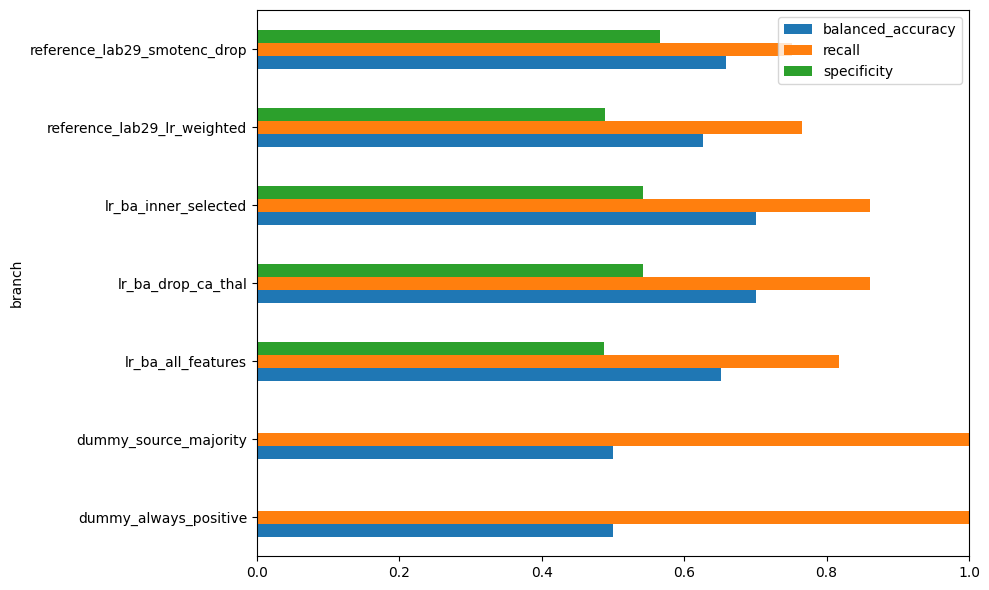

ZIP: /content/uci_multicenter_lr_balanced_accuracy_lab30_results.zip
Macro = equal hospital weighting. Worst-site = worst seed-averaged hospital.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
METRICS=['balanced_accuracy','accuracy','recall','specificity','precision','f1',
         'roc_auc','average_precision','brier']
site_summary=results.groupby(['branch','site'])[METRICS].mean().reset_index()
macro_summary=site_summary.groupby('branch')[METRICS].mean()
worst=site_summary.groupby('branch').agg(worst_balanced_accuracy=('balanced_accuracy','min'),
    worst_recall=('recall','min'),worst_specificity=('specificity','min'),
    worst_accuracy=('accuracy','min'),worst_auc=('roc_auc','min'),worst_brier=('brier','max'))
macro_summary=macro_summary.join(worst).reset_index()
seed_summary=results.groupby(['branch','seed'])[METRICS].mean().reset_index()
paired_frames=[]
for reference in ['reference_lab29_lr_weighted','reference_lab29_smotenc_drop']:
    base=results[results.branch==reference][['site','seed']+METRICS]
    paired=results.merge(base,on=['site','seed'],suffixes=('','_reference'),validate='many_to_one')
    paired['reference']=reference
    for metric in METRICS: paired['delta_'+metric]=paired[metric]-paired[metric+'_reference']
    paired_frames.append(paired)
paired=pd.concat(paired_frames,ignore_index=True)
with pd.option_context('display.max_rows',None,'display.max_columns',None):
    display(macro_summary.sort_values('balanced_accuracy',ascending=False).round(4))
    display(site_summary.round(4))
    display(selections)
artifacts=dict(raw_results=results,predictions=predictions,site_summary=site_summary,
    macro_summary=macro_summary,seed_summary=seed_summary,paired_deltas=paired,
    tuning=pd.DataFrame(tuning_rows),selected_configs=selections)
for name,frame in artifacts.items(): frame.to_csv(OUTPUT_DIR/(name+'.csv'),index=False)
run_config=dict(notebook='Lab30',C_grid=C_GRID,weight_grid=WEIGHT_GRID,seeds=MODEL_SEEDS,
    threshold=THRESHOLD,primary_metric='macro inner-hospital balanced accuracy',
    secondary_tie_break='minimum inner-hospital balanced accuracy, then grid order',
    references='Lab29 C grid selected by macro inner Accuracy',
    development_sites=DEVELOPMENT_SITES,external_holdout_loaded=False,
    versions={p:importlib.metadata.version(p) for p in ['numpy','pandas','scikit-learn','imbalanced-learn']})
(OUTPUT_DIR/'run_config.json').write_text(json.dumps(run_config,indent=2),encoding='utf-8')
ax=macro_summary.set_index('branch')[['balanced_accuracy','recall','specificity']].plot.barh(figsize=(10,6))
ax.set_xlim(0,1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'balanced_accuracy_comparison.png',dpi=160)
plt.show()
print('ZIP:',shutil.make_archive(str(OUTPUT_DIR),'zip',OUTPUT_DIR))
print('Macro = equal hospital weighting. Worst-site = worst seed-averaged hospital.')

## Cách kết luận
- So sánh paired deltas với hai references trên cùng outer hospital/seed.
- Ưu tiên macro Balanced Accuracy; kiểm tra worst-site BA và riêng Recall/Specificity.
- `lr_ba_inner_selected` là quy trình chọn feature trong inner CV; không tự chọn nhánh theo outer ranking.
- Không diễn giải SD qua seeds thành độ chắc chắn của hiệu quả ở bệnh viện mới.
- Chỉ 8 ca âm ở Switzerland: Specificity có thể biến động mạnh.
- Hungarian không tham gia; không tuyên bố kết quả là external blind validation.

Tham khảo: [Steyerberg & Harrell, 2016](https://doi.org/10.1016/j.jclinepi.2015.04.005),
[Varma & Simon, 2006](https://doi.org/10.1186/1471-2105-7-91).